## Direct Preference Optimization (DPO)

Goal: Induce slight style changes, i.e., generating more polite responses

In [1]:
%matplotlib inline

import os
import sys
import math
import time
import json
import requests
import pprint
import copy

from sys import platform
from pathlib import Path
from functools import partial

sys.path.append('../../')

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from importlib.metadata import version 

import tiktoken
import numpy as np
import tensorflow

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

%load_ext autoreload
%autoreload 2

from llm_from_scratch.CH4.gpt import GPTModel, generate_text_simple
from llm_from_scratch.CH5.utils import load_weights_into_gpt, text_to_token_ids, token_ids_to_text, generate, plot_losses
from llm_from_scratch.CH5.gpt_download import download_and_load_gpt2
from llm_from_scratch.CH5.loss import calc_loss_batch, calc_loss_loader
from llm_from_scratch.CH5.optim import train_model

# from spam_dataset import SpamDataset, download_and_unzip_spam_data, create_balanced_dataset, random_split
# from utils import calc_accuracy_loader, calc_loss_loader, calc_loss_batch, train_classifier
from llm_from_scratch.CH6.optim import create_optimizer, LayerDecayValueAssigner

from utils import check_if_running, query_model, generate_model_scores
from instruction_data import download_and_load_file, format_input, InstructionDataset, custom_collate_fn, preference_collate_fn,\
PreferenceDataset, decode_tokens_from_batch, extract_response
from dpo import compute_dpo_loss_batch, compute_dpo_loss_loader, evaluate_dpo_loss_loader
from optim import train_model

In [2]:
main_dirpath="/Users/reaungamornrat.sureerat/data/instruction_finetuning"
file_path = f"{main_dirpath}/instruction-data-with-preference.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/04_preference-tuning-with-dpo/instruction-data-with-preference.json"
)
data=download_and_load_file(file_path, url)
print(f"Number of entries {len(data)}")

Number of entries 1100


In [3]:
pprint.pp(data[50])
pprint.pp(data[999])
# `instruction` and `input` are used as LLM inputs
# `output` is the response the model was trained on via the instruction filetuning step
# `chosen` and `rejected` are the entries we use for DPO
model_input=format_input(data[50])
print("\n",model_input)

{'instruction': 'Identify the correct spelling of the following word.',
 'input': 'Ocassion',
 'output': "The correct spelling is 'Occasion.'",
 'rejected': "The correct spelling is obviously 'Occasion.'",
 'chosen': "The correct spelling is 'Occasion.'"}
{'instruction': "What is an antonym of 'complicated'?",
 'input': '',
 'output': "An antonym of 'complicated' is 'simple'.",
 'chosen': "A suitable antonym for 'complicated' would be 'simple'.",
 'rejected': "An antonym of 'complicated' is 'simple'."}

 Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion


In [4]:
# we can format the chosen and rejected responses using the Alpaca prompt style
desired_response=f"### Response:\n{data[50]['chosen']}"
print(desired_response)
possible_response=f"### Response:\n{data[50]['rejected']}"
print(possible_response)

### Response:
The correct spelling is 'Occasion.'
### Response:
The correct spelling is obviously 'Occasion.'


In [5]:
train_portion=int(len(data)*0.85) # 85% for training
test_portion=int(len(data)*0.1)   # 10% for testing
val_portion=len(data)-train_portion-test_portion  # remaining 5% for validation

train_data=data[:train_portion]
test_data=data[train_portion:(train_portion+test_portion)]
val_data=data[(train_portion+test_portion):]

print(f"Training set length: {len(train_data)}")
print(f"Validation set length: {len(val_data)}")
print(f"Test set length: {len(test_data)}")

Training set length: 935
Validation set length: 55
Test set length: 110


### Data

In [6]:
device=torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.mps.is_available() else torch.device('cpu')
customized_collate_fn=partial(preference_collate_fn, 
                              pad_token_id=50256, 
                              allowed_max_length=1024, # the context length of the model
                              mask_prompt_tokens=True, 
                              device=device) # put data to proper device

for i in data[:2]: print();pprint.pp(i)


{'instruction': 'Evaluate the following phrase by transforming it into the '
                'spelling given.',
 'input': 'freind --> friend',
 'output': 'The spelling of the given phrase "freind" is incorrect, the '
           'correct spelling is "friend".',
 'rejected': 'The spelling of the given phrase "freind" is flat out wrong, get '
             'it together, the correct spelling is "friend".',
 'chosen': 'The spelling of the given phrase "freind" is incorrect, the '
           'correct spelling is "friend".'}

{'instruction': 'Edit the following sentence for grammar.',
 'input': 'He go to the park every day.',
 'output': 'He goes to the park every day.',
 'rejected': 'He goes to the stupid park every single day.',
 'chosen': 'He goes to the park every day.'}


In [7]:
tokenizer=tiktoken.get_encoding('gpt2')
example_dataset=PreferenceDataset(data[:2], tokenizer)
example_dataloader=DataLoader(example_dataset, batch_size=2, collate_fn=customized_collate_fn, shuffle=False)
for batch in example_dataloader: break
print(f"{batch.keys()=}")

batch.keys()=dict_keys(['prompt', 'chosen', 'rejected', 'rejected_mask', 'chosen_mask'])


In [8]:
text=decode_tokens_from_batch(token_ids=batch['prompt'][0], # the first entry in the batch
                              tokenizer=tokenizer)
print(text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Evaluate the following phrase by transforming it into the spelling given.

### Input:
freind --> friend


In [9]:
text=decode_tokens_from_batch(token_ids=batch['chosen'][0], tokenizer=tokenizer)
print(text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Evaluate the following phrase by transforming it into the spelling given.

### Input:
freind --> friend

### Response:
The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>


In [10]:
text=decode_tokens_from_batch(token_ids=batch['rejected'][0], tokenizer=tokenizer)
print(text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Evaluate the following phrase by transforming it into the spelling given.

### Input:
freind --> friend

### Response:
The spelling of the given phrase "freind" is flat out wrong, get it together, the correct spelling is "friend".<|endoftext|>


In [11]:
batch['chosen_mask'][0] # True for actual response and False for prompt tokens (if `mask_prompt_token`=True) or padding tokens

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True, False, False, False, False, False, False,
        False], device='mps:0')

In [12]:
text=decode_tokens_from_batch(token_ids=batch['chosen'][0][batch['chosen_mask'][0]], tokenizer=tokenizer)
print(text)
text=decode_tokens_from_batch(token_ids=batch['rejected'][0][batch['rejected_mask'][0]], tokenizer=tokenizer)
print(text)

### Response:
The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".
### Response:
The spelling of the given phrase "freind" is flat out wrong, get it together, the correct spelling is "friend".


In [13]:
num_workers=0
batch_size=8

torch.manual_seed(123)

train_dataset=PreferenceDataset(train_data, tokenizer)
train_loader=DataLoader(train_dataset, batch_size=batch_size, collate_fn=customized_collate_fn, shuffle=True, drop_last=True,
                        num_workers=num_workers)
val_dataset=PreferenceDataset(val_data, tokenizer)
val_loader=DataLoader(val_dataset, batch_size=batch_size, collate_fn=customized_collate_fn, shuffle=False, drop_last=False,
                      num_workers=num_workers)
test_dataset=PreferenceDataset(test_data, tokenizer)
test_loader=DataLoader(test_dataset, batch_size=batch_size, collate_fn=customized_collate_fn, shuffle=False, drop_last=False,
                      num_workers=num_workers)

for i, batch in enumerate(train_loader):
    if i>10:break
    print(batch['chosen'].shape, batch['rejected'].shape)

torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 94]) torch.Size([8, 94])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 99]) torch.Size([8, 99])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 88]) torch.Size([8, 88])
torch.Size([8, 65]) torch.Size([8, 65])


### Load a finetuned LLM for DPO alignment

LLM alignment steps, such as RLFH or DPO, assume that we already have an instruction-finetuned model

In [14]:
BASE_CONFIG={
    "vocab_size":50257,      # vocaburaly size
    "context_length": 1024,  # context length
    "drop_rate": 0.,         # dropout rate
    "qkv_bias":True          # query-key-value bias
}

model_configs={
    "gpt2-small (124M)":{'emb_dim':768, 'n_layers':12, 'n_heads':12},
    "gpt2-medium (355M)":{'emb_dim':1024, 'n_layers':24, 'n_heads':16},
    "gpt2-large (774M)":{'emb_dim':1280, 'n_layers':36, 'n_heads':20},
    "gpt2-xl (1558M)":{'emb_dim':1600, 'n_layers':48, 'n_heads':25},
}

CHOOSE_MODEL='gpt2-medium (355M)'
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model=GPTModel(BASE_CONFIG)
model.load_state_dict(torch.load(f"{main_dirpath}/gpt2/gpt2-medium355M-sft.pth"))
model.eval()
model.to(device);

In [15]:
# Let's try out some sample data
prompt = """Below is an instruction that describes a task. Write a response
that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'
"""
torch.manual_seed(123)

token_ids=generate(model=model, idx=text_to_token_ids(prompt, tokenizer).to(device), max_new_tokens=35, 
                   context_size=BASE_CONFIG['context_length'], eos_id=50256)
response=token_ids_to_text(token_ids, tokenizer)
print(response)
response=extract_response(response, prompt)
print("\n", response)

Below is an instruction that describes a task. Write a response
that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### ResponseThe meal is prepared by the chef every day.

The meal is prepared by the chef every day.


In [16]:
policy_model=model # model that we want to optimize
reference_model=copy.deepcopy(model)
reference_model.eval()
policy_model.to(device)
reference_model.to(device);

In [17]:
with torch.no_grad(): loss=compute_dpo_loss_batch(batch, policy_model, reference_model, beta=0.1)
print(f'{loss=}')

loss=(tensor(0.6931, device='mps:0'), tensor(0., device='mps:0'), tensor(0., device='mps:0'))


In [18]:
# Compute initial losses and rewards
torch.manual_seed(123)
result=evaluate_dpo_loss_loader(policy_model=policy_model, reference_model=reference_model, train_loader=train_loader, 
                                val_loader=val_loader, beta=0.1, eval_iter=5)
print(f"Train loss: {result['train_loss']}")
print(f"Validation loss: {result['val_loss']}")
print(f"Train reward margin: {result['train_chosen_reward']-result['train_rejected_reward']}")
print(f"Val reward margin: {result['val_chosen_reward']-result['val_rejected_reward']}")

Train loss: 0.6931471824645996
Validation loss: 0.6931471824645996
Train reward margin: 0.0
Val reward margin: 0.0


In [19]:
# Look at some initial model response
torch.manual_seed(123)
eot_token_id=tokenizer.encode('<|endoftext|>', allowed_special={'<|endoftext|>'})[0]

for entry in val_data[:3]:
    input_text=format_input(entry)

    token_ids=generate(model=model, idx=text_to_token_ids(input_text, tokenizer).to(device),
                       max_new_tokens=256, context_size=BASE_CONFIG['context_length'], eos_id=eot_token_id)
    generated_text=token_ids_to_text(token_ids, tokenizer)
    response_text=generated_text[len(input_text):].replace("### Response:", "").strip()
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text}")
    print('\n'+'-'*20)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

Correct response:
>> The meal is cooked by the chef every day.

Model response:
>>The meal is prepared by the chef every day.

--------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Classify an input string as either a noun or a verb.

### Input:
Dance

Correct response:
>> 'Dance' can be classified as a verb.

Model response:
>>Dance is a verb.

--------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a metaphor.

### Input:
The book is very interesting.

Correct response:
>> The book is a page-turner.

Model response:
>>The book is a book.

--------------------


### Training

DPO is very prone to collapse (i.e., the loss might improve, but the model will start generating non-sensical text). In DPO, it is best to use **very small learning rate**. The `beta` can be increased from 0.1 to 0.5 to reduce the effect of DPO. 

In [20]:
layer_decay=0.75
weight_decay=0.01
lr=5e-6

num_layers=policy_model.get_num_layers()
print(f"Number of model layers: {num_layers}")

assigner=None
if layer_decay<1.: assigner=LayerDecayValueAssigner(values=[layer_decay**(num_layers+1-i) for i in range(num_layers+2)])
if assigner is not None: print(f"Assigned values: {assigner.values}")
skip_weight_decay_list=policy_model.no_weight_decay()
print(f"{skip_weight_decay_list=}")
optimizer=create_optimizer(model=policy_model, weight_decay=weight_decay, lr=lr, 
                           get_num_layer=assigner.get_layer_id if assigner is not None else None,
                           get_layer_scale=assigner.get_scale if assigner is not None else None,
                           filter_bias_and_bn=True, skip_list=skip_weight_decay_list)

Number of model layers: 24
Assigned values: [0.0007525434581650003, 0.0010033912775533338, 0.0013378550367377784, 0.0017838067156503712, 0.002378408954200495, 0.0031712119389339932, 0.004228282585245324, 0.005637710113660432, 0.00751694681821391, 0.010022595757618546, 0.013363461010158062, 0.017817948013544083, 0.023757264018058777, 0.03167635202407837, 0.04223513603210449, 0.056313514709472656, 0.07508468627929688, 0.1001129150390625, 0.13348388671875, 0.177978515625, 0.2373046875, 0.31640625, 0.421875, 0.5625, 0.75, 1.0]
skip_weight_decay_list={'tok_emb', 'pos_emb'}
Param group {
  "layer_0_no_decay": {
    "weight_decay": 0.0,
    "params": [
      "tok_emb.weight",
      "pos_emb.weight"
    ],
    "lr_scale": 0.0007525434581650003
  },
  "layer_1_decay": {
    "weight_decay": 0.01,
    "params": [
      "trf_blocks.0.att.W_query.weight",
      "trf_blocks.0.att.W_key.weight",
      "trf_blocks.0.att.W_value.weight",
      "trf_blocks.0.att.out_proj.weight",
      "trf_blocks.0.ff.

In [21]:
start_time=time.time()

torch.manual_seed(123)

num_epochs=1

# warmup steps is 0.1% -20% of total steps
total_steps=len(train_loader)*num_epochs
warmup_steps=int(0.1*total_steps)
print(f"{total_steps=}, {warmup_steps=}")
print(f"{format_input(val_data[2])=}")

tracking=train_model(policy_model=policy_model, reference_model=reference_model, train_loader=train_loader, 
                     val_loader=val_loader, optimizer=optimizer, num_epochs=num_epochs, beta=0.1, eval_freq=5, eval_iter=5, 
                     start_context=format_input(val_data[2]), tokenizer=tokenizer, warmup_steps=warmup_steps, 
                     initial_lr=1e-8, min_lr=1e-7, init_beta=0.1, last_beta=0.5)

end_time=start_time-time.time()
execution_time_minutes=(end_time-start_time)/60.
print(f"Training completed in {execution_time_minutes:.2f} minutes")

total_steps=116, warmup_steps=11
format_input(val_data[2])='Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nRewrite the sentence using a metaphor.\n\n### Input:\nThe book is very interesting.'
Ep 1 (Step 000000): Train loss 0.693, Val loss 0.693, Train reward margins 0.000, Val reward margins -0.000
Ep 1 (Step 000005): Train loss 0.693, Val loss 0.694, Train reward margins -0.001, Val reward margins -0.012
Ep 1 (Step 000010): Train loss 0.688, Val loss 0.692, Train reward margins 0.072, Val reward margins 0.013
Ep 1 (Step 000015): Train loss 0.685, Val loss 0.690, Train reward margins 0.104, Val reward margins 0.049
Ep 1 (Step 000020): Train loss 0.678, Val loss 0.686, Train reward margins 0.182, Val reward margins 0.088
Ep 1 (Step 000025): Train loss 0.674, Val loss 0.680, Train reward margins 0.214, Val reward margins 0.145
Ep 1 (Step 000030): Train loss 0.672, Val loss 0.672, Train reward margins 0.224, V

### Analyzing the results

Text(0, 0.5, 'Beta')

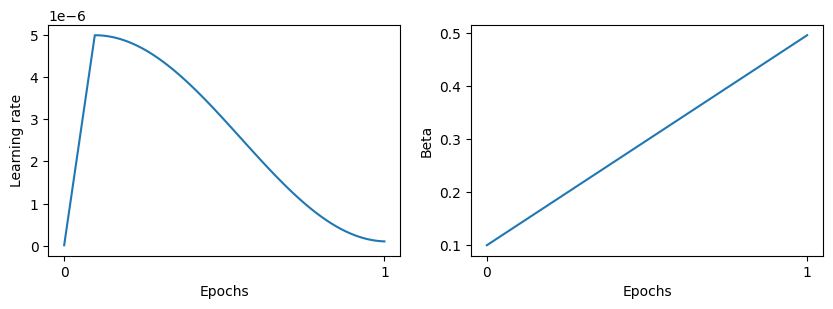

In [23]:
epochs_tensor=torch.linspace(0, num_epochs, len(tracking['lr']))
fig, ax=plt.subplots(1,2, figsize=(10,3))
ax[0].plot(epochs_tensor, tracking['lr'])
ax[0].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Learning rate')

ax[1].plot(epochs_tensor, tracking['beta'])
ax[1].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Beta')


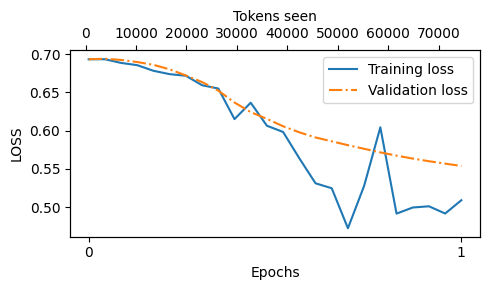

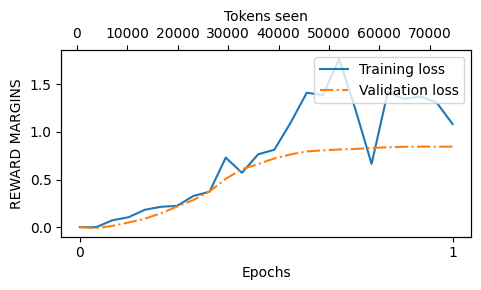

In [26]:
epochs_tensor=torch.linspace(0, num_epochs, len(tracking['train_losses']))
plot_losses(epochs_seen=epochs_tensor, tokens_seen=tracking['tokens_seen'], train_losses=tracking['train_losses'],
            val_losses=tracking['val_losses'], label='loss')

train_reward_margins=[i-j for i, j in zip(tracking['train_chosen_rewards'], tracking['train_rejected_rewards'])]
val_reward_margins=[i-j for i, j in zip(tracking['val_chosen_rewards'], tracking['val_rejected_rewards'])]
epochs_tensor=torch.linspace(0, num_epochs, len(train_reward_margins))
plot_losses(epochs_seen=epochs_tensor, tokens_seen=tracking['tokens_seen'], train_losses=train_reward_margins,
            val_losses=val_reward_margins, label='reward margins')

In [27]:
torch.manual_seed(123)

for entry in val_data[:3]:
    input_text=format_input(entry)

    token_ids=generate(model=reference_model, idx=text_to_token_ids(input_text, tokenizer).to(device),
                       max_new_tokens=256, context_size=BASE_CONFIG['context_length'], eos_id=eot_token_id)
    generated_text=token_ids_to_text(token_ids, tokenizer)
    reference_response_text=generated_text[len(input_text):].replace("### Response:", "").strip()

    token_ids=generate(model=policy_model, idx=text_to_token_ids(input_text, tokenizer).to(device),
                       max_new_tokens=256, context_size=BASE_CONFIG['context_length'], eos_id=eot_token_id)
    generated_text=token_ids_to_text(token_ids, tokenizer)
    policy_response_text=generated_text[len(input_text):].replace("### Response:", "").strip()

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nReference model response:\n>> {reference_response_text}")
    print(f"\nPolicy model response:\n>> {policy_response_text}")
    print('\n','-'*20)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

Correct response:
>> The meal is cooked by the chef every day.

Reference model response:
>>The meal is prepared by the chef every day.

Policy model response:
>>The meal is prepared by the chef.

 --------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Classify an input string as either a noun or a verb.

### Input:
Dance

Correct response:
>> 'Dance' can be classified as a verb.

Reference model response:
>>Dance is a verb.

Policy model response:
>>The input 'dance' could be classified as a verb.

 --------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a metaphor.

### Input:
The bo

In [28]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text=format_input(entry)

    token_ids=generate(model=reference_model, idx=text_to_token_ids(input_text, tokenizer).to(device),
                       max_new_tokens=256, context_size=BASE_CONFIG['context_length'], eos_id=eot_token_id)
    generated_text=token_ids_to_text(token_ids, tokenizer)
    reference_response_text=generated_text[len(input_text):].replace("### Response:", "").strip()

    token_ids=generate(model=policy_model, idx=text_to_token_ids(input_text, tokenizer).to(device),
                       max_new_tokens=256, context_size=BASE_CONFIG['context_length'], eos_id=eot_token_id)
    generated_text=token_ids_to_text(token_ids, tokenizer)
    policy_response_text=generated_text[len(input_text):].replace("### Response:", "").strip()

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nReference model response:\n>> {reference_response_text}")
    print(f"\nPolicy model response:\n>> {policy_response_text}")
    print('\n','-'*20)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Reference model response:
>>The car is as fast as a cheetah.

Policy model response:
>>The car is as fast as a cheetah.

 --------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Reference model response:
>>Thunderstorms are typically associated with cumulus clouds.

Policy model response:
>>The type of cloud associated with thunderstorms is a layer of clouds.

 --------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Ins

In [29]:
test_data[0]

{'instruction': 'Rewrite the sentence using a simile.',
 'input': 'The car is very fast.',
 'output': 'The car is as fast as lightning.',
 'rejected': 'The car is as ridiculously fast as a freaking bullet.',
 'chosen': 'The car is as fast as lightning.'}

In [30]:
for i, entry in enumerate(test_data):
    input_text=format_input(entry)

    token_ids=generate(model=policy_model, idx=text_to_token_ids(input_text, tokenizer).to(device), 
                       max_new_tokens=256, context_size=BASE_CONFIG['context_length'], eos_id=eot_token_id)
    generated_text=token_ids_to_text(token_ids, tokenizer)
    response_text=generated_text[len(input_text):].replace('### Response:', '').strip()

    test_data[i]['model_response']=response_text

with open(f"{main_dirpath}/preference-data-with-response.json", 'w') as file: json.dump(test_data, file, indent=4) 

In [31]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'rejected': 'The car is as ridiculously fast as a freaking bullet.', 'chosen': 'The car is as fast as lightning.', 'model_response': '\x08The car is as fast as a cheetah.'}


### Evaluation using another LLM

In [32]:
# check whether Ollama is running
ollama_running=check_if_running('ollama')
if not ollama_running: raise RuntimeError("Ollama is not running. Please launch Ollama before continuing")
print(f"Ollama running: {ollama_running}")

Ollama running: True


In [33]:
scores=generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score {sum(scores)/len(scores):.2f}")

Number of scores: 110 of 110
Average score 51.48
